For performing new tracing first import and make Tracer object based on config file settings.
The config file contains locations of images and ROIs for tracing, as well as settings for tracing, quality control and data output and saving.

If the analysis has already been run before, we can load the data instead:

In [1]:
import pandas as pd
import numpy as np
import os
import chromatin_tracing_python.image_processing_functions as ip
import chromatin_tracing_python.tracing_functions as tr
from chromatin_tracing_python.tracer_h5 import Tracer_decon

T=Tracer_decon(r"M:\ChromatinTeam\Images_processing\20200603_Exp328_KSB_Elyra_tracing_myc_D1-10\20200604_Exp_328_tracing_config_decon_h5.yaml")
wdir = r"M:\ChromatinTeam\Images_processing\20200603_Exp328_KSB_Elyra_tracing_myc_D1-10\04_TRACING"+os.sep
traces = pd.read_hdf(wdir+"20200603_Exp328_KSB_Elyra_tracing_myc_D1-10_v1_decon__traces.h5")
imgs=np.moveaxis(ip.read_tif_image(wdir+'20200603_Exp328_KSB_Elyra_tracing_myc_D1-10_v1_decon__imgs.tiff'),1,2)

traces=T.reapply_QC(traces)

Once we have the traces loaded or calculated, we can look at the trace dataframe. It has a multilevel index with a unique trace ID as main index, and image name, nuclear ownership and frame nr as secondary index for each point. Each fitted point is documented with the full output of the gaussian fit, as well as a quality control metric defined from the config file. Units in nm.

In [2]:
traces.query('trace_ID == 63')

,img_name,roi_ID,frame,BG,A,z_px,y_px,x_px,sigma_z,sigma_xy,z,y,x,QC
trace_ID,,,,,,,,,,,,,,
63,20200603_328_tracing_D1_D10_exp_DE_2_W0006_P00...,9,0,257.700469,26301.307656,9.639712,16.589694,17.001853,212.941296,93.333725,1927.942454,1609.200303,1649.179758,0
63,20200603_328_tracing_D1_D10_exp_DE_2_W0006_P00...,9,1,339.333420,33639.972014,9.699080,16.572617,17.036189,204.364392,88.117297,1939.816062,1607.543822,1652.510373,1
63,20200603_328_tracing_D1_D10_exp_DE_2_W0006_P00...,9,2,315.671991,28434.582408,9.599505,16.636257,17.058139,205.424328,89.993394,1919.900935,1613.716910,1654.639480,1
63,20200603_328_tracing_D1_D10_exp_DE_2_W0006_P00...,9,3,315.167541,29012.199969,9.649446,16.576774,17.072262,208.456269,91.223653,1929.889294,1607.947094,1656.009408,1
63,20200603_328_tracing_D1_D10_exp_DE_2_W0006_P00...,9,4,285.925677,28231.292057,9.643086,16.624000,17.092277,201.729746,91.473177,1928.617188,1612.527972,1657.950825,1
63,20200603_328_tracing_D1_D10_exp_DE_2_W0006_P00...,9,5,253.670045,28884.589064,9.615047,16.497684,17.084871,199.038667,88.156059,1923.009354,1600.275340,1657.232445,1
63,20200603_328_tracing_D1_D10_exp_DE_2_W0006_P00...,9,6,253.868399,26172.258368,9.611768,16.604193,17.047723,202.689364,90.036687,1922.353532,1610.606755,1653.629102,1
63,20200603_328_tracing_D1_D10_exp_DE_2_W0006_P00...,9,7,295.390704,32643.531198,9.628539,16.651430,17.102343,201.902180,88.642024,1925.707817,1615.188698,1658.927295,1
63,20200603_328_tracing_D1_D10_exp_DE_2_W0006_P00...,9,8,282.756908,29972.344031,9.662878,16.622894,17.135047,194.400280,86.142774,1932.575686,1612.420761,1662.099566,1


We can easily visualize one or more traces by their trace_IDs now, either one or several (by a list of trace_IDs). To do this we load the tracing functions module that contains several helper functions for trace analysis.

In [3]:
tr.plot_traces(traces,[26])

['E1', 'E2', 'E3', 'E5', 'E7', 'E8', 'E9', 'E11']


Let us get some more statistics on our traces:

In [4]:
import plotly.express as px
px.histogram(traces.groupby(level='trace_ID').sum(), x='QC', width=500)

In [5]:
px.bar(traces.groupby('frame').sum(), y='QC', width=500)

Visualize fits on top of actual image data using napari.

In [6]:
import napari
points=tr.points_for_overlay(traces.query('QC == 1'))
with napari.gui_qt():
    viewer = napari.view_image(np.moveaxis(np.max(imgs,axis=2),0,1), contrast_limits=(100,10000))
    viewer.add_points(points[:,(0,1,3,4)], size=[0,0,1,1], face_color='red', symbol='cross', n_dimensional=True)

Depending on the quality of the dataset, some traces might be too short for a useful anaylsis. These can be filtered out from the traces and pair-wise distance matrix before analysing further. Once filtered, we can get a sense of the data from the average pwd matrix (missing distances are nan, so we have to use nanmean).

In [7]:
traces_long = tr.tracing_length_qc(traces, min_length=9)
pwds_long = tr.pwd_calc(traces_long)

In [8]:
print('Number of traces in analysis: ', pwds_long.shape[0])
pwds_mean=np.clip(np.round(-np.nanmedian(pwds_long, axis=0),0).astype(int),-300,0)

import plotly.figure_factory as ff
fig = ff.create_annotated_heatmap(pwds_mean,colorscale='hot')
fig.update_layout(
    width = 600,
    height = 600,
    yaxis_autorange="reversed"
)
fig.show()

Number of traces in analysis:  115


Further, we can do a paired analysis on traces to figure out similarities between sets of traces. The output of this analysis contains the original indexes and point coordinates of the two compared indexes, the second trace aligned to the first by least squares fitting, and three metrics of similarity between the two traces. These are the mse of the alignment, and the mse of the two pair-wise distance matrices, as well as the Pearson's correlation coefficient between the PWDs. We sort the matrix for to find pairs with a high PCC.

In [9]:
pairs = tr.trace_analysis(traces_long, pwds_long)

In [10]:
pairs.sort_values(by=['aligned_mse'], ascending=True).head()

,idx1,idx2,aligned_mse,aligned_pcc,pwd_mse,pwd_pcc
3943,63,88,16.483784,0.993619,14.023407,0.200421
4878,81,135,48.793416,0.987057,67.988998,0.647237
3398,56,60,57.213730,0.952361,63.482644,0.552281
3468,56,156,61.976757,0.951793,75.015795,0.704064
2703,40,135,71.698889,0.971665,67.974077,0.765329


We can visualize the aligned traces by their index in the pair matrix.

In [11]:
tr.plot_aligned_traces(traces,[56,156])

We can immediately use the paired similarity values to group the traces. We can use any of the three similarity metrics defined in the pairs analysis. This constructs a dendrogram showing simple hierichal grouping of the dataset. The labels in the dendrogram are the original trace_id of each trace.

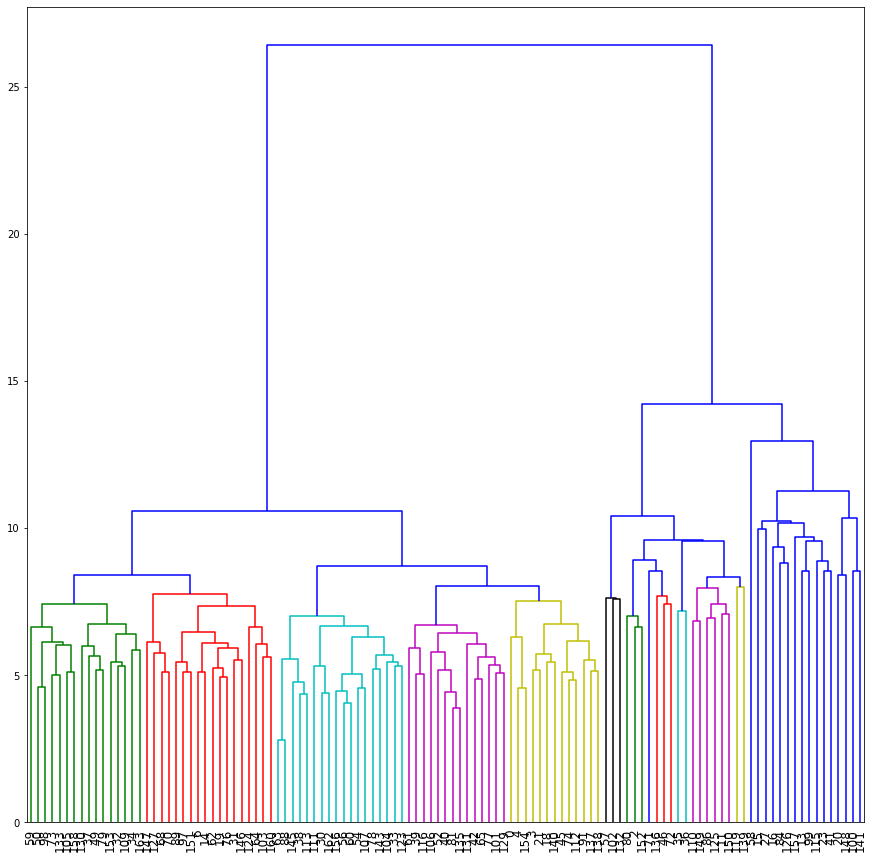

In [12]:
cluster_df = tr.trace_clustering(pairs, metric='aligned_mse', method='ward', color_threshold=8)

In [13]:
cluster_id = 1
cluster_members = cluster_df[cluster_df['cluster']==cluster_id]['trace_ID'].values
print(cluster_members)

[ 32  34  37  49  50  59  73  79  98 105 109 130 133 153 158 163]


In [14]:
clust_aligned, clust_mean = tr.general_procrustes_analysis(traces, cluster_members)
tr.plot_gpa_output(clust_aligned, clust_mean)

Initial distance is 2524.5460620953186
GPA converged after 5 cycles with distance 671.9071774461415
[ 1  2  3  4  5  6  7  8  9 10 11]


We can visualize these individually as before. To visualize pairs in the identified grouping, we can look up the index in the pairs analysis and plot these using the paired plotting function as well. Note that for lookups in the pairs dataframe the lower index is always idx1, the higher idx2.

In [15]:
aligned_all_gpa=tr.run_gpa_all_clusters(traces_long, cluster_df, 3)
tr.plot_multi_points(aligned_all_gpa)

[[32, 34, 37, 49, 50, 59, 73, 79, 98, 105, 109, 130, 133, 153, 158, 163], [6, 14, 19, 31, 62, 64, 68, 70, 76, 89, 97, 103, 124, 127, 146, 147, 151, 160], [30, 33, 38, 54, 56, 60, 63, 78, 88, 104, 107, 111, 113, 123, 143, 145, 156, 162], [39, 40, 42, 52, 61, 65, 77, 81, 101, 106, 116, 129, 131, 135], [0, 3, 4, 18, 21, 45, 74, 91, 112, 137, 138, 140, 154], [57, 102, 132], [2, 80, 152], [46, 72, 136], [11, 86, 110, 125, 149, 150]]
Initial distance is 2677.4953727831466
GPA converged after 4 cycles with distance 671.906365910784
Initial distance is 2996.499752767079
GPA converged after 10 cycles with distance 814.7086071713414
Initial distance is 2383.2884497898003
GPA converged after 5 cycles with distance 733.5695465396227
Initial distance is 1907.538060278373
GPA converged after 4 cycles with distance 579.525375513416
Initial distance is 1794.3326517560981
GPA converged after 5 cycles with distance 491.8559350954947
Initial distance is 373.8012368833434
GPA converged after 2 cycles with